# Решающие деревья

### Вспомним линейные модели

1) Какие линейные модели мы прошли?
2) Какие у линейных моделей преимущества? Какие недостатки?

### Что такое решающие деревья?!

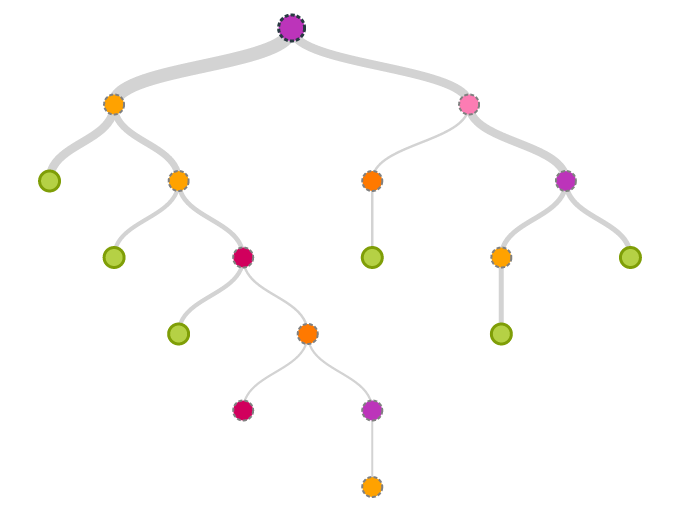



**Решающие деревья** — это модели, которые принимают решения, задавая последовательность простых вопросов.
Каждый вопрос делит данные на группы, пока не получится понятное правило для классификаци

Представь, что мы хотим определить, пойдёшь ли ты гулять:


> Если на улице дождь → не идти

> Иначе, если холодно → не идти

> Иначе → идти

### Как работает дерево

1. Находит признак, который лучше всего делит данные на группы (например, “Температура > 20°C?”).

2. Делит данные по этому признаку.

3. Повторяет процесс для каждой полученной группы, пока не достигнет “чистых” подмножеств, где почти все объекты одного класса.


# Примеры

In [ ]:
# Датасет ирисов
from sklearn.datasets import load_iris # загружаем библиотеку с датасетом
from sklearn import tree # загружаем библиотеку для построения модели решающего дерева
iris = load_iris() # загружаем данные
clf = tree.DecisionTreeClassifier() # задаем модель, которую будем использовать
X = iris.data # Признаки
y = iris.target # Целевая переменная
clf = clf.fit(X, y) # обучаем модель на данных
clf

DecisionTreeClassifier()

In [ ]:
# Датасет Титаник
import pandas as pd
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
data_train.loc[data_train.Sex == 'male','Sex'] = 1
data_train.loc[data_train.Sex == 'female','Sex'] = 2

data_train.loc[data_train.Embarked == 'S','Embarked'] = 1
data_train.loc[data_train.Embarked == 'C','Embarked'] = 2
data_train.loc[data_train.Embarked == 'Q','Embarked'] = 3

data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,38.0,1,0,PC 17599,71.2833,C85,2
2,3,1,3,"Heikkinen, Miss. Laina",2,26.0,0,0,STON/O2. 3101282,7.9250,NaN,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,35.0,1,0,113803,53.1000,C123,1
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,1


In [ ]:
data_test.loc[data_test.Sex == 'male','Sex'] = 1
data_test.loc[data_test.Sex == 'female','Sex'] = 2

data_test.loc[data_test.Embarked == 'S','Embarked'] = 1
data_test.loc[data_test.Embarked == 'C','Embarked'] = 2
data_test.loc[data_test.Embarked == 'Q','Embarked'] = 3

data_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",1,34.5,0,0,330911,7.8292,NaN,3
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",2,47.0,1,0,363272,7.0000,NaN,1
2,894,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,240276,9.6875,NaN,3
3,895,3,"Wirz, Mr. Albert",1,27.0,0,0,315154,8.6625,NaN,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",2,22.0,1,1,3101298,12.2875,NaN,1


In [ ]:
data_train.loc[data_train.Age.isnull(),'Age'] = data_train['Age'].median()
data_train.loc[data_train.Fare.isnull(),'Fare'] = data_train['Fare'].median()

data_test.loc[data_test.Age.isnull(),'Age'] = data_test['Age'].median()
data_test.loc[data_test.Fare.isnull(),'Fare'] = data_test['Fare'].median()

In [ ]:
X = data_train.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1).values
y = data_train['Survived'].values

In [ ]:
clf = tree.DecisionTreeClassifier() # задаем модель, которую будем использовать
clf = clf.fit(X, y) # обучаем модель на данных
clf

DecisionTreeClassifier()

In [ ]:
# Делаем предсказания для тестовой выборки
X_test = data_test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1).values
y_test = clf.predict(X_test)

In [ ]:
submission = pd.DataFrame({
        "PassengerId": data_test["PassengerId"],
        "Survived": y_test
    })
submission.to_csv('submission.csv', index=False)

# Случайный лес

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Обучаем модель
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X, y)

RandomForestClassifier(max_depth=2, random_state=0)

In [ ]:
# Делаем предсказания для тестовой выборки
y_test = clf.predict(X_test)

In [ ]:
submission = pd.DataFrame({
        "PassengerId": data_test["PassengerId"],
        "Survived": y_test
    })
submission.to_csv('submission_rf.csv', index=False)

# Кросс-валидация и перебор параметров

In [ ]:
# Оценка качества работы модели на кросс-валидации
from sklearn.model_selection import cross_val_score
print(cross_val_score(clf, X, y))
print(cross_val_score(clf, X, y).mean())

[ 0.78787879  0.8047138   0.78451178]
0.792368125701


In [ ]:
# Перебор параметров с помощью GridSearch
from sklearn.model_selection import GridSearchCV
parameters = {'max_depth':[2,3,4,5], 'min_samples_leaf':[1, 2, 5, 8], 'n_estimators': [10, 100, 1000]}
rf = RandomForestClassifier()
clf = GridSearchCV(rf, parameters)
clf.fit(X, y)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 3, 4, 5],
                         'min_samples_leaf': [1, 2, 5, 8],
                         'n_estimators': [10, 100, 1000]})

In [ ]:
print('Лучшая точность модели: ', clf.best_score_)
print('Параметры, при которых достигается лучшая точность: ', clf.best_params_)

Лучшая точность модели:  0.8282844768062269
Параметры, при которых достигается лучшая точность:  {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 100}


In [ ]:
submission = pd.DataFrame({
        "PassengerId": data_test["PassengerId"],
        "Survived": clf.predict(X_test)
    })
submission.to_csv('submission_grid.csv', index=False)